In [ ]:
import kagglehub
import pandas as pd

# Download dataset
path = kagglehub.dataset_download("jmcaro/wheat-seedsuci")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'wheat-seedsuci' dataset.
Dataset Path: /kaggle/input/wheat-seedsuci


In [ ]:
import pandas as pd
import os

print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "seeds.csv"))
df.info()

['.nfs0000000037b211af0000000c', 'seeds.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             199 non-null    float64
 1   Perimeter        199 non-null    float64
 2   Compactness      199 non-null    float64
 3   Kernel.Length    199 non-null    float64
 4   Kernel.Width     199 non-null    float64
 5   Asymmetry.Coeff  199 non-null    float64
 6   Kernel.Groove    199 non-null    float64
 7   Type             199 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv(os.path.join(path, "seeds.csv"))

# Display first 5 rows
df.head()

,Area,Perimeter,Compactness,Kernel.Length,Kernel.Width,Asymmetry.Coeff,Kernel.Groove,Type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [ ]:
print("First 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

First 5 Rows
    Area  Perimeter  Compactness  Kernel.Length  Kernel.Width  \
0  15.26      14.84       0.8710          5.763         3.312   
1  14.88      14.57       0.8811          5.554         3.333   
2  14.29      14.09       0.9050          5.291         3.337   
3  13.84      13.94       0.8955          5.324         3.379   
4  16.14      14.99       0.9034          5.658         3.562   

   Asymmetry.Coeff  Kernel.Groove  Type  
0            2.221          5.220     1  
1            1.018          4.956     1  
2            2.699          4.825     1  
3            2.259          4.805     1  
4            1.355          5.175     1  

Last 5 Rows
      Area  Perimeter  Compactness  Kernel.Length  Kernel.Width  \
194  12.19      13.20       0.8783          5.137         2.981   
195  11.23      12.88       0.8511          5.140         2.795   
196  13.20      13.66       0.8883          5.236         3.232   
197  11.84      13.21       0.8521          5.175         2.836

In [ ]:
print(df.isnull().sum())

Area               0
Perimeter          0
Compactness        0
Kernel.Length      0
Kernel.Width       0
Asymmetry.Coeff    0
Kernel.Groove      0
Type               0
dtype: int64


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

In [ ]:
X = df.drop("Type", axis=1)
Y = df["Type"]

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
Y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(Y_test, Y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9


In [ ]:
cm = confusion_matrix(Y_test, Y_pred)

print(cm)

[[ 6  0  3]
 [ 0 19  0]
 [ 1  0 11]]


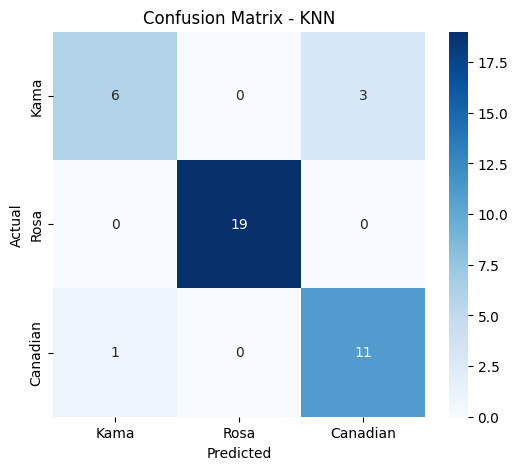

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kama", "Rosa", "Canadian"],
    yticklabels=["Kama", "Rosa", "Canadian"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")

plt.show()

In [ ]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           1       0.86      0.67      0.75         9
           2       1.00      1.00      1.00        19
           3       0.79      0.92      0.85        12

    accuracy                           0.90        40
   macro avg       0.88      0.86      0.87        40
weighted avg       0.90      0.90      0.90        40



In [ ]:
new_seed = [[15.2,14.5,0.88,5.7,3.3,2.2,5.1]]

new_seed = scaler.transform(new_seed)

prediction = model.predict(new_seed)

print("Predicted Class :", prediction[0])

Predicted Class : 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
print("Training Accuracy :", model.score(X_train, Y_train))

print("Testing Accuracy :", model.score(X_test, Y_test))

Training Accuracy : 0.9811320754716981
Testing Accuracy : 0.9


In [ ]:
new_data = [
    [15.2,14.5,0.88,5.7,3.3,2.2,5.1],
    [13.5,13.8,0.85,5.0,3.0,2.0,4.8],
    [18.0,16.5,0.90,6.2,3.8,2.8,6.0]

]

new_data = scaler.transform(new_data)

prediction = model.predict(new_data)

print(prediction)

[1 1 2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


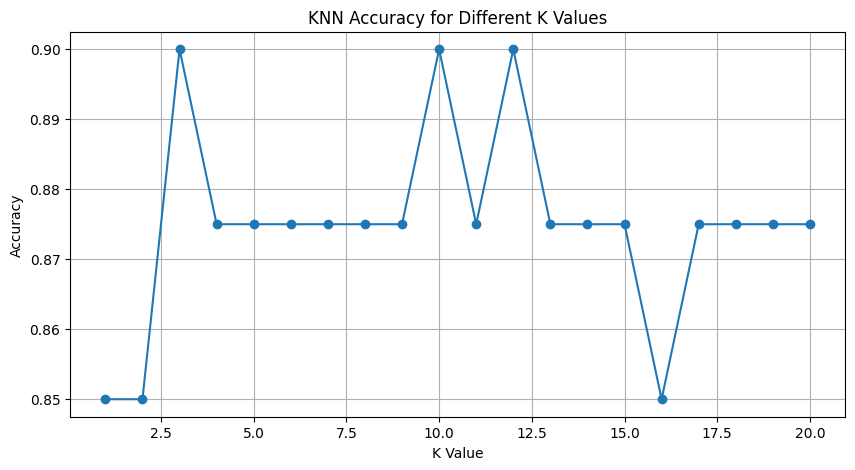

Best Accuracy : 0.9


In [ ]:
accuracy = []

for k in range(1,21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train,Y_train)

    pred = knn.predict(X_test)

    accuracy.append(accuracy_score(Y_test,pred))

plt.figure(figsize=(10,5))

plt.plot(range(1,21),accuracy,marker="o")

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("KNN Accuracy for Different K Values")

plt.grid()

plt.show()

print("Best Accuracy :", max(accuracy))

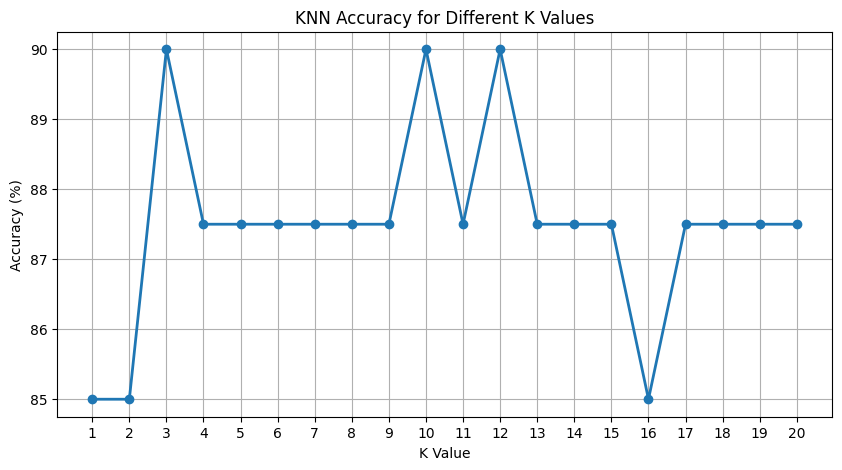

Best K: 3
Best Accuracy: 90 %


In [ ]:
accuracy = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, Y_train)

    pred = knn.predict(X_test)

    accuracy.append(accuracy_score(Y_test, pred) * 100)

best_accuracy = max(accuracy)
best_k = accuracy.index(best_accuracy) + 1
plt.figure(figsize=(10,5))

plt.plot(range(1,21), accuracy, marker="o", linewidth=2)

plt.xticks(range(1,21))   # Show every K value from 1 to 20

plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.title("KNN Accuracy for Different K Values")

plt.grid(True)

plt.show()
print("Best K:", best_k)
print("Best Accuracy:", int(best_accuracy), "%")